In [ ]:
import gymnasium as gym
import highway_env
from stable_baselines3 import PPO
from tqdm import trange

gym.register_envs(highway_env)

: 

In [ ]:
import numpy as np

model = PPO.load("PPO_1/final_model.zip")
env = gym.make("merge-v0")

NUM_EPISODES = 100000
successes = 0
failures = 0

collision_positions = []  # (x, y) of ego at crash
collision_speeds = []     # ego speed at crash
collision_types = []      # 'merger' or 'highway'

for episode in trange(NUM_EPISODES):
    obs, info = env.reset()
    done = truncated = False
    merger = env.unwrapped.road.vehicles[-1]  # capture reference at reset, before any steps

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)

    vehicle = env.unwrapped.vehicle
    if getattr(vehicle, 'crashed', False):
        failures += 1
        collision_positions.append(vehicle.position.copy())
        collision_speeds.append(vehicle.speed)

        # If merger also crashed, they collided with each other
        hit_merger = merger.crashed
        collision_types.append('merger' if hit_merger else 'highway')
    else:
        successes += 1

env.close()

merger_fails  = collision_types.count('merger')
highway_fails = collision_types.count('highway')
p_fail = failures / NUM_EPISODES

print(f"Successes:      {successes}/{NUM_EPISODES}")
print(f"Failures:       {failures}/{NUM_EPISODES}")
print(f"  Merger:       {merger_fails} ({merger_fails/NUM_EPISODES*100:.2f}%)")
print(f"  Highway:      {highway_fails} ({highway_fails/NUM_EPISODES*100:.2f}%)")
print(f"P(failure) ≈    {p_fail:.4f}  ({p_fail*100:.2f}%)")

/home/jahall21/miniconda3/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
  2%|▏         | 1577/100000 [05:18<5:22:19,  5.09it/s]

In [6]:
# Cell for loading experiments from eval_merge_ppop.py
import numpy as np
NUM_EPISODES = 100000
successes = 97921
failures = 2079
p_fail = failures / NUM_EPISODES

collision_positions = np.load("collision_positions.npy").tolist()
collision_speeds = np.load("collision_speeds.npy").tolist()
collision_types = np.load("collision_types.npy", allow_pickle=True).tolist()

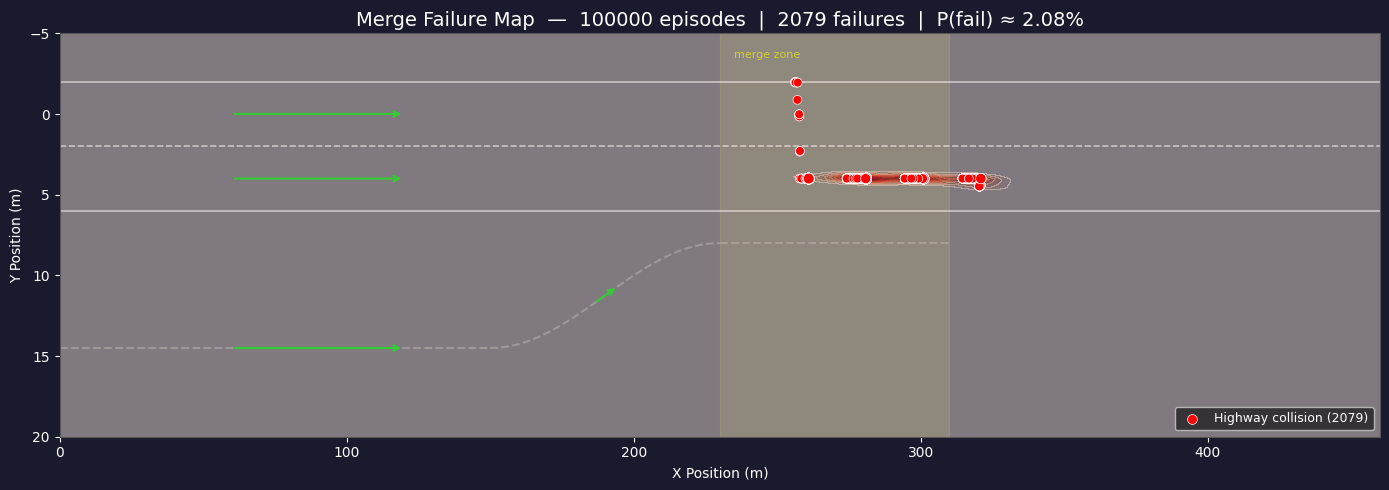

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

# Road geometry (from merge_env.py)
LANE_W = 4.0
ends = [150, 80, 80, 150]
x_total = sum(ends)  # 460m

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

# --- Road geometry ---
# Highway lane boundaries (solid=outer, dashed=center divider)
for y, ls in [(-LANE_W/2, '-'), (LANE_W/2, '--'), (LANE_W + LANE_W/2, '-')]:
    ax.axhline(y, color='white', lw=1.2, ls=ls, alpha=0.6)

# Merge zone shading (x=230 to 310)
ax.axvspan(sum(ends[:2]), sum(ends[:3]), alpha=0.12, color='yellow', zorder=1)
ax.text(sum(ends[:2]) + 5, -3.5, 'merge zone', color='yellow', alpha=0.6, fontsize=8)

# Merge ramp: straight section x=0..150 at y=14.5
ax.plot([0, ends[0]], [14.5, 14.5], color='#888', lw=1.5, ls='--', alpha=0.5)

# Sine curve x=150..230 curving from y=14.5 down to y=8
x_sine = np.linspace(ends[0], sum(ends[:2]), 100)
y_sine = 11.25 + 3.25 * np.sin(np.pi / ends[1] * (x_sine - ends[0]) + np.pi / 2)
ax.plot(x_sine, y_sine, color='#888', lw=1.5, ls='--', alpha=0.5)

# Merge ramp straight section x=230..310 at y~8
ax.plot([sum(ends[:2]), sum(ends[:3])], [8.0, 8.0], color='#888', lw=1.5, ls='--', alpha=0.5)

# --- Direction arrows ---
arrow_kw = dict(arrowstyle='->', color='limegreen', lw=1.5)
# Highway flow (two lanes)
for lane_y in [0.0, LANE_W]:
    ax.annotate('', xy=(120, lane_y), xytext=(60, lane_y),
                arrowprops=dict(**arrow_kw), zorder=4)
# Merge ramp flow (straight section)
ax.annotate('', xy=(120, 14.5), xytext=(60, 14.5),
            arrowprops=dict(**arrow_kw), zorder=4)
# Merge ramp flow (along sine curve, at midpoint)
mid = len(x_sine) // 2
ax.annotate('', xy=(x_sine[mid+5], y_sine[mid+5]), xytext=(x_sine[mid-5], y_sine[mid-5]),
            arrowprops=dict(**arrow_kw), zorder=4)

# --- KDE heatmap (only if enough points) ---
if len(collision_positions) >= 5:
    pts = np.array(collision_positions).T
    kde = gaussian_kde(pts, bw_method=0.4)
    xi = np.linspace(0, x_total, 400)
    yi = np.linspace(-5, 20, 150)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    ax.contourf(Xi, Yi, Zi, levels=12, cmap='Reds', alpha=0.45, zorder=2)
else:
    ax.text(x_total / 2, 10, f'Need more failures for KDE\n(have {len(collision_positions)})',
            ha='center', color='white', alpha=0.5, fontsize=9)

# --- Scatter collision points ---
if collision_positions:
    xs = [p[0] for p in collision_positions]
    ys = [p[1] for p in collision_positions]
    sizes = [max(40, s * 3) for s in collision_speeds]  # larger dot = faster at crash

    merger_idx  = [i for i, t in enumerate(collision_types) if t == 'merger']
    highway_idx = [i for i, t in enumerate(collision_types) if t == 'highway']

    if merger_idx:
        ax.scatter([xs[i] for i in merger_idx], [ys[i] for i in merger_idx],
                   s=[sizes[i] for i in merger_idx], c='dodgerblue', zorder=5,
                   edgecolors='white', lw=0.5, label=f'Merger collision ({len(merger_idx)})')
    if highway_idx:
        ax.scatter([xs[i] for i in highway_idx], [ys[i] for i in highway_idx],
                   s=[sizes[i] for i in highway_idx], c='red', zorder=5,
                   edgecolors='white', lw=0.5, label=f'Highway collision ({len(highway_idx)})')

ax.set_xlim(0, x_total)
ax.set_ylim(-5, 20)
ax.invert_yaxis()  # match highway-env screen coords (y increases downward)
ax.set_xlabel('X Position (m)', color='white')
ax.set_ylabel('Y Position (m)', color='white')
ax.set_title(
    f'Merge Failure Map  —  {NUM_EPISODES} episodes  |  {failures} failures  |  P(fail) ≈ {p_fail*100:.2f}%',
    color='white', fontsize=14
)
ax.tick_params(colors='white')
ax.legend(loc='lower right', facecolor='#222', labelcolor='white', fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#555')

plt.tight_layout()
plt.savefig("merge_failure_map.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()